In [54]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import emcee
import corner

For the start, the code is exactly the same.

In [55]:
# Constants
M_sun = 2e33             # Solar mass in g
M_tot = 0.01 * M_sun     # Total mass of the ejecta in g
c = 3e10                 # Speed of light in cm/s
v_min = 0.1 * c          # Minimum velocity of massive shell in cm/s
beta = 3                 # factor for homologous expansion - ensures shells never overlap 
numshells = 10           # Number of shells

#Time array
t = np.logspace(0, 6, 50)              
# Velocity array for each shell
v_shells = np.linspace(0.1, 1, numshells)* c

# Mass distribution
M_shells = beta * M_tot * (v_min**(beta)) * (v_shells**(-beta-1))    # Mass fraction based on velocity
M_shells = M_shells * M_tot / np.sum(M_shells)                       # Normalised so the shells sum to M_0
E_int_shells =  0.5 * M_shells * (v_shells**2)                     # Internal energy per shell, assming kinetic energy is similar to internal energy

#Dataframe of properties
shell_data = pd.DataFrame({'Velocity (cm/s)': v_shells, 'Mass (g)': M_shells, 'Internal Energy (erg)': E_int_shells})

# Constants associated with heating and radiative loss terms
av = 0.56
bv = 0.71
cv = 0.74
xr = 0.6
kv = [20, 5, 1]                  # Opacity ranges for kilonova colors

# Heating efficiency as a function of time
def eps_th_v(t):
    t_day = t / 86400  # Convert seconds to days
    exp_term = np.exp(-av * t_day)
    log_term = np.log(1 + 2 * bv * t_day**cv)
    result = 0.36 * (exp_term + (log_term / (2 * bv * t_day**cv)))
    return result

# R-process energy deposition rate
def e_dot_r(t):
    t0 = 1.3  
    sigma = 0.11  
    arctan_term = np.arctan((t - t0) / sigma)
    result = 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * arctan_term)**1.3
    return result

# Heating due to radioactive decay
def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

# Diffusion time
def t_diff(M_shells, t):
    return ((M_shells**(4./3.)) * kv[2]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

# Radiative losses
def L_v(R, Eint, t_diff):
    t_lc = (R / c)                            # Light-crossing time
    return Eint / (t_diff + t_lc)

# ODEs governing energy and dynamics
def energy(y, t, M):
    Eint, R, v = y
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]
# Solving for each shell
E_all = []
R_all = []
v_all = []
t_peak = []
lv_values = []
for i, row in shell_data.iterrows():
    M = row['Mass (g)']
    Eint0 = row['Internal Energy (erg)']
    v0 = row['Velocity (cm/s)']
    R0 = 1e9  # Initial radius
    y0 = [Eint0, R0, v0]
    Edep = odeint(energy, y0, t, args=(M,))
    E_all.append(Edep[:, 0])  
    R_all.append(Edep[:, 1])  
    v_all.append(Edep[:, 2])
    t_peak.append(t_diff(M,t))
    lv_values.append(L_v(R0,Eint0,t_diff(M,t))) 
lv_values = np.array(lv_values)
print(lv_values.shape)

(10, 50)


In [56]:

M_all = np.array(shell_data['Mass (g)']).squeeze() 
R_all = np.array(R_all)  

def compute_photosphere_radius(R_all, shell_masses, t):

    num_shells, num_times = R_all.shape
    R_ph = np.zeros(num_times)
    
    for i in range(num_times):
       
        tau_cumu = 0.0
        tau_list = []
        R_list = []
    
        for j in range(num_shells - 1, -1, -1):
            R_curr = R_all[j, i]
      
          
            d_tau = kv[2] * shell_masses[j] / (4 * np.pi * R_curr**2)
          
            tau_cumu += d_tau
            tau_list.append(tau_cumu)
            R_list.append(R_curr)
    
        tau_array = np.array(tau_list)
        
        R_array = np.array(R_list)
    
       
        if tau_array[-1] < 1:
            R_ph[i] = R_array[-1]
        else:
            indices = np.where(tau_array >= 1)[0]
            idx = indices[0]
            if idx == 0:
                R_ph[i] = R_array[0]
            else:
                
                tau_low = tau_array[idx - 1]
                tau_high = tau_array[idx]
                R_low = R_array[idx - 1]
                R_high = R_array[idx]
                f = (1 - tau_low) / (tau_high - tau_low)
                R_ph[i] = R_low + f * (R_high - R_low)
                
    
    return R_ph
R_ph = compute_photosphere_radius(R_all, M_shells, t)

[14548245.237057487, 2267921.1176108117, 1312163.3328761489, 926143.1762232282, 709139.2501012222, 566945.6514986686, 465196.7632049622, 388186.84994536394, 327647.06416915584, 278769.51180487487, 238540.016280643, 204950.5917147059, 176592.61220535793, 152431.28029057838, 131673.52531050335, 113688.47240689238, 97962.33837335354, 84081.58622019077, 71740.33100090887, 60755.48676694782, 51055.76346495559, 43431.428284777765, 37404.81964070768, 32121.88511530192, 27822.916736656833, 24373.89560998446, 21249.750557774878, 18700.241095166675, 16615.629522695122, 14638.19071571827, 13084.17270796394, 11665.553447784003, 10286.352722207172, 9391.29593819644, 8321.39069255792, 7263.140270453298, 6439.01874566297, 5925.134500405994, 5286.437302260376, 4555.092750863147, 3959.877785337821, 3445.8311164149823, 2977.9911440067053, 2552.447080812809, 2216.5540711316085, 1814.9187831043419, 1297.592103542622, 929.5465600941558, 682.3558180464875, 512.6153930502237]


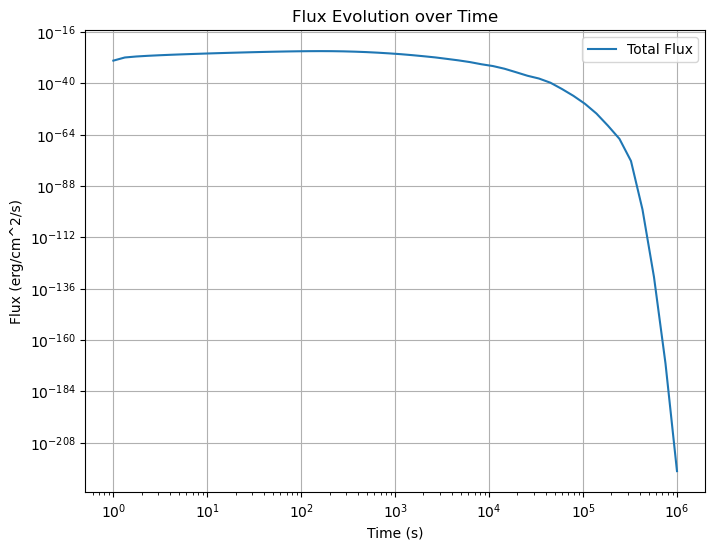

In [57]:
L_tot = np.sum([L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t)) 
                for i, (R, Eint) in enumerate(zip(R_all, E_all))], axis=0)

sigma = 5.67e-5    # Stefan's constant in erg / cm^2 / s / K^4
h = 6.626e-27      # Planck's constant in erg * s
nu = 5e15          # Frequency (Hz), can be altered to see fluxes of different frequencies
kB = 1.38e-16      # Boltzmann's constant in erg / K
D = 1e25           # Luminosity distance in cm, as used by Metzger in his paper (100 Mpc)

T_eff = []
for i in range(len(R_ph)):
    T_eff_shell = (L_tot[i] / (4*np.pi *sigma*(R_ph[i]**2)))**(1/4)
    T_eff.append(T_eff_shell)

print(T_eff)

Flux = []
for i in range(len(T_eff)):
    Flux_shell = ((2 * np.pi * h * (nu**3)) / (c**2)) * (1 / (np.exp((h * nu) / (kB * T_eff[i])) - 1)) * (R_ph[i]**2 / D**2)
    Flux.append(Flux_shell)  # Append the flux for each shell

Flux = np.array(Flux)

# Plotting the flux
plt.figure(figsize=(8, 6))
plt.loglog(t, Flux, label='Total Flux')  # Plot the total flux (sum of all shells)
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm^2/s)')
plt.title('Flux Evolution over Time')
plt.grid(True)
plt.legend()
plt.show()

C:\Users\olibr\AppData\Local\Temp\ipykernel_23888\1876008428.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e6])


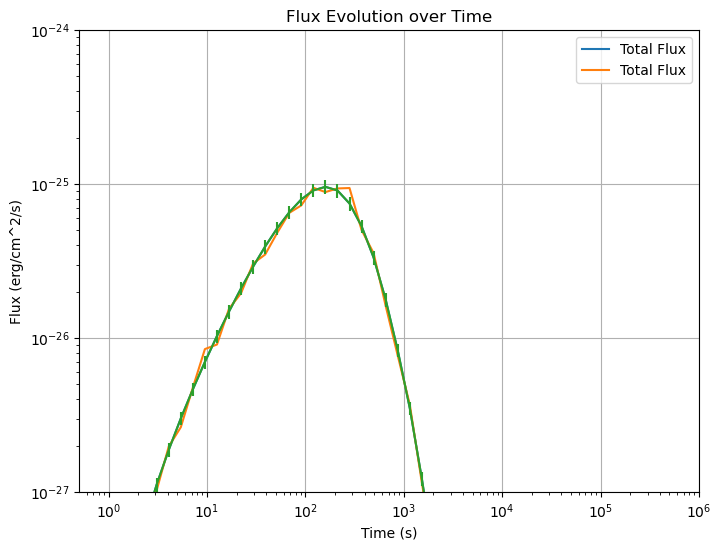

In [ ]:
noise = 0.1*Flux  # Add noise
Flux_perturbed = Flux + noise * np.random.randn(*Flux.shape)

plt.figure(figsize=(8, 6))
plt.loglog(t, Flux, label='Total Flux')  # Plot the total flux (sum of all shells)
plt.loglog(t, Flux_perturbed, label='Total Flux')  # Plot the total flux (sum of all shells)
plt.errorbar(t, Flux, yerr = noise)
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm^2/s)')
plt.xlim([0, 1e6])
plt.ylim([1e-27, 1e-24])
plt.title('Flux Evolution over Time')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
theta = M_tot, Eint0, R0, v0
def model(theta, t=t):
    theta = M_tot, Eint0, R0, v0
    model = Flux
    return model

In [ ]:
theta = M_tot, Eint0, R0, v0
def model(theta, t=t):
    theta = M_tot, Eint0, R0, v0
    model = Flux
    return model

def log_likelihood(theta, t, y, yerr):
 
    Loglike = -0.5 * np.sum(((y - model)/(yerr))**2)
    return Loglike

In [ ]:
#Assign priors and reasonable ranges
def log_prior(theta):    
    if 1e20 < M < M_sun and 1e40 < Eint0 < 1e51 and 1e9 < R0 < 1e17 and 1e8 < v0 < 1e10: 
        return 0.0  # Wanted outcome
    return -np.inf 

def log_posterior(theta, t, y, yerr):
    lp = log_prior(theta)
    if np.isinf(lp):
        return lp
    return lp + log_likelihood(theta, t, y, yerr)      # Applying likelihood to priors

ndim = 4
nwalkers = 1000
nsteps = 10000   

mass_noise_scale = 0.1  
Eint0_noise_scale = 0.1  
v0_noise_scale = 0.05  
R0_noise_scale = 0.05

# Initialize the walkers' positions
initial = np.array([M_tot, Eint0, v0, R0]) + np.array([mass_noise_scale * M_tot, Eint0_noise_scale * Eint0, v0_noise_scale * v0, R0_noise_scale * R0]) * np.random.randn(nwalkers, ndim)

initial = np.maximum(initial, 1e-10)  # Avoid negative or zero values

# Run the MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, Flux, noise))
sampler.run_mcmc(initial, nsteps, progress=True)

# Extract the samples
samples = sampler.get_chain(discard=1000, thin=10, flat=True)

  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\olibr\pythonconda\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [01:01<00:00, 163.34it/s]


In [84]:
print(samples.shape)  
print(np.ptp(samples, axis=0))   # Test for issues, equals zero if the system has failed.

(900000, 4)
[1.37358259e+31 4.85465768e+47 9.01612188e+09 3.26349918e+08]


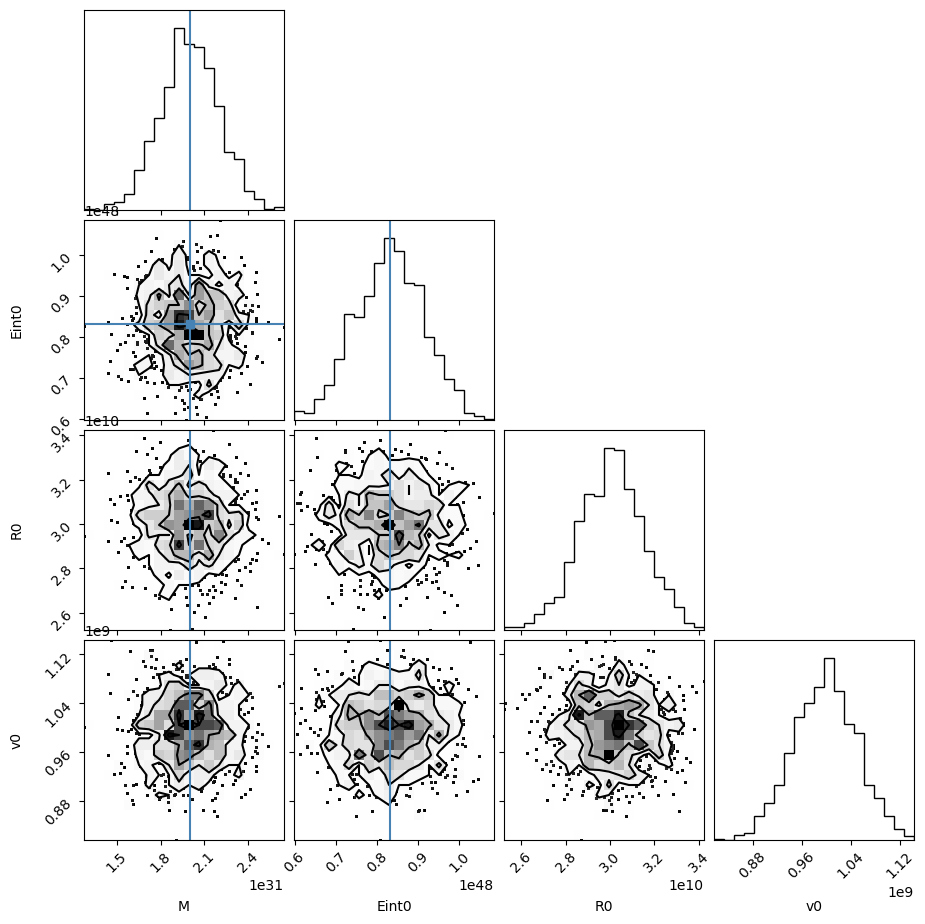

In [85]:
figure = corner.corner(samples, labels=["M", "Eint0", "R0", "v0"], truths=[M_tot, Eint0, R0, v0])
plt.show()